<a href="https://colab.research.google.com/github/jiyeonlee-2930/Tourist-Prediction-Project-2026/blob/main/02_GA_ACO_BP_%EB%AA%A8%EB%8D%B8%EB%A7%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

# 구글 드라이브 마운트 (연결)
drive.mount('/content/drive')

# 작업 경로를 '정선군 프로젝트' 폴더로 이동
import os
os.chdir('/content/drive/MyDrive/정선군 프로젝트')

print("✅ 구글 드라이브 연결 및 작업 경로 이동 완료!")
# 현재 폴더 안에 있는 파일/폴더 목록 확인
print(os.listdir('.'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 구글 드라이브 연결 및 작업 경로 이동 완료!
['data', 'models', 'docs', '01_데이터전처리.ipynb', '02_GA_ACO_BP_모델링.ipynb']


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. 마스터 데이터 불러오기
file_path = "data/어린이대공원_GA_ACO_BP_마스터데이터.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")

# 2. 결측치(빈칸) 해결
df = df.ffill().bfill()

# ★ 옵션 B 적용: '검색량' 데이터에 로그 변환(Log Transformation) 적용
# np.log1p는 데이터가 0일 때 에러가 나지 않도록 1을 더한 후 로그를 씌워줍니다.
df['검색량'] = np.log1p(df['검색량'])

# 3. 입력 변수(X)와 정답 타겟(y) 분리
X_data = df.drop(columns=['입장일', '총입장객수']).values
y_data = df['총입장객수'].values.reshape(-1, 1)

# 4. 데이터 정규화 (Min-Max Scaling)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

# 5. Train(학습용) / Test(평가용) 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, shuffle=False)

# 6. PyTorch 텐서(Tensor) 변환
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

print("✅ 검색량 로그 변환 및 데이터 준비 완료! (스파이크 억제 장착)")
print(f"🔹 입력 변수(X) 개수(입력층 노드 수): {X_train_tensor.shape[1]}개")
print(f"🔹 학습용 데이터 크기: {X_train_tensor.shape[0]}일")
print(f"🔹 평가용 데이터 크기: {X_test_tensor.shape[0]}일")

✅ 검색량 로그 변환 및 데이터 준비 완료! (스파이크 억제 장착)
🔹 입력 변수(X) 개수(입력층 노드 수): 11개
🔹 학습용 데이터 크기: 584일
🔹 평가용 데이터 크기: 147일


In [ ]:
import torch
import torch.nn as nn

# 1. BP 신경망 클래스(Class) 정의
class BP_Network(nn.Module):
    def __init__(self, input_size=11, hidden_size=8, output_size=1):
        super(BP_Network, self).__init__()

        # 첫 번째 관문: 입력층(11개 노드)에서 은닉층(8개 노드)으로 연결
        self.hidden_layer = nn.Linear(input_size, hidden_size)

        # 활성화 함수: 데이터의 비선형적인 패턴(날씨, 휴일 등)을 학습하게 해주는 핵심 역할
        self.relu = nn.ReLU()

        # 두 번째 관문: 은닉층(8개 노드)에서 출력층(1개 노드 = 최종 방문객 수)으로 연결
        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # 데이터가 신경망을 통과하는 순서 정의
        x = self.hidden_layer(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

# 2. 모델 인스턴스 생성 및 구조 확인
# 입력 노드 11개, 은닉 노드 8개(논문 참고), 출력 노드 1개 세팅
bp_model = BP_Network(input_size=11, hidden_size=8, output_size=1)

print(" BP 신경망 뼈대 설계 완료!")
print(bp_model)

 BP 신경망 뼈대 설계 완료!
BP_Network(
  (hidden_layer): Linear(in_features=11, out_features=8, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
)


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import copy

# --- 1. 유전 알고리즘을 위한 가중치 변환 도우미 함수 ---
def get_params(model):
    # 모델의 모든 가중치와 편향을 1차원 배열(하나의 염색체)로 길게 폅니다.
    return np.concatenate([p.data.cpu().numpy().flatten() for p in model.parameters()])

def set_params(model, chromosome):
    # 1차원 배열(염색체)을 다시 BP 신경망의 원래 가중치 모양으로 조립해서 넣습니다.
    idx = 0
    for p in model.parameters():
        size = p.numel()
        p.data = torch.tensor(chromosome[idx:idx+size].reshape(p.shape)).float()
        idx += size

# --- 2. 유전 알고리즘(GA) 하이퍼파라미터 세팅 ---
POP_SIZE = 20         # 염색체 무리(개체군) 크기: 논문과 동일하게 20개 세팅
GENERATIONS = 50      # 세대 수: 50번의 진화(교차/변이) 반복
MUTATION_RATE = 0.1   # 돌연변이 확률: 10% (국소 최적해 탈출용)

# BP 신경망의 총 가중치 개수 파악 (우리가 만든 모델은 총 105개의 가중치를 가짐)
num_params = len(get_params(bp_model))
print(f" 1개의 염색체가 가진 유전자(가중치) 개수: {num_params}개\n")

# 초기 개체군 생성 (20개의 무작위 가중치 세트를 산맥 곳곳에 흩뿌림)
population = np.random.uniform(-1.0, 1.0, (POP_SIZE, num_params))
best_ga_chromosome = None
best_fitness = float('inf') # 오차(MSE)를 측정하므로 숫자가 작을수록(0에 가까울수록) 우수함

loss_fn = nn.MSELoss()

# 적합도(오차) 평가 함수
def evaluate(chromosome):
    set_params(bp_model, chromosome)
    bp_model.eval()
    with torch.no_grad():
        pred = bp_model(X_train_tensor)
        loss = loss_fn(pred, y_train_tensor).item()
    return loss

# --- 3. 본격적인 유전 알고리즘(GA) 진화 루프 시작 ---
print(" 유전 알고리즘(GA) 전역 탐색을 시작합니다...\n")

for gen in range(GENERATIONS):
    # 1) 현재 세대 모든 개체의 적합도(오차) 평가
    fitness_scores = np.array([evaluate(ind) for ind in population])

    # 2) 이번 세대에서 가장 오차가 적은 1등 개체 저장 (우수 유전자 보존)
    current_best_idx = np.argmin(fitness_scores)
    if fitness_scores[current_best_idx] < best_fitness:
        best_fitness = fitness_scores[current_best_idx]
        best_ga_chromosome = population[current_best_idx].copy()

    # 3) 선택 (Selection) - 토너먼트 방식
    # 무작위로 3개를 뽑아 그 중 가장 우수한 개체를 부모로 선발
    new_population = []
    for _ in range(POP_SIZE):
        candidates = np.random.choice(POP_SIZE, 3, replace=False)
        winner = candidates[np.argmin(fitness_scores[candidates])]
        new_population.append(population[winner])
    new_population = np.array(new_population)

    # 4) 교차 (Crossover) - 선발된 두 부모의 유전자를 반반씩 섞음
    for i in range(0, POP_SIZE, 2):
        if np.random.rand() < 0.8: # 80% 확률로 교차 발생
            crossover_point = np.random.randint(1, num_params)
            parent1, parent2 = new_population[i].copy(), new_population[i+1].copy()
            new_population[i, crossover_point:] = parent2[crossover_point:]
            new_population[i+1, crossover_point:] = parent1[crossover_point:]

    # 5) 변이 (Mutation) - 엉뚱한 곳(돌연변이)으로 튀게 만들어 얕은 골짜기 탈출
    for i in range(POP_SIZE):
        if np.random.rand() < MUTATION_RATE:
            mutation_point = np.random.randint(num_params)
            new_population[i, mutation_point] += np.random.uniform(-0.5, 0.5)

    # 새로운 세대로 교체
    population = new_population

    # 10세대마다 진행 상황 출력
    if (gen+1) % 10 == 0:
        print(f"▶ {gen+1}세대 완료 | 현재 발견한 최소 오차(MSE): {best_fitness:.4f}")

print("\n GA 전역 탐색 완료! 가장 훌륭한 '대략적인 명당(유력 지역)'의 좌표를 찾았습니다.")

 1개의 염색체가 가진 유전자(가중치) 개수: 105개

 유전 알고리즘(GA) 전역 탐색을 시작합니다...

▶ 10세대 완료 | 현재 발견한 최소 오차(MSE): 0.0257
▶ 20세대 완료 | 현재 발견한 최소 오차(MSE): 0.0210
▶ 30세대 완료 | 현재 발견한 최소 오차(MSE): 0.0206
▶ 40세대 완료 | 현재 발견한 최소 오차(MSE): 0.0199
▶ 50세대 완료 | 현재 발견한 최소 오차(MSE): 0.0199

 GA 전역 탐색 완료! 가장 훌륭한 '대략적인 명당(유력 지역)'의 좌표를 찾았습니다.


In [ ]:
import numpy as np

# 🚨 안전장치: GA가 바통을 제대로 넘겼는지 확인
if 'best_ga_chromosome' not in globals() or best_ga_chromosome is None:
    raise ValueError(" GA 최적화 결과가 없습니다! 이전 단계(Phase 2) 셀을 먼저 끝까지 실행해주세요.")

# --- 1. 개미 군집 최적화(ACO) 하이퍼파라미터 세팅 ---
ANT_COUNT = 20
ACO_ITERATIONS = 30
EVAPORATION_RATE = 0.9

# ★ GA와 ACO의 핵심 연결 고리 ★
pheromone_center = best_ga_chromosome.copy()

# 탐색 반경 설정 (이미 GA가 좁혀놨기 때문에 넓게 뛸 필요 없이 0.1 반경에서 시작)
search_radius = 0.1

best_aco_chromosome = pheromone_center.copy()
best_aco_fitness = best_fitness # GA의 최고 기록을 기준점으로 시작

print(" 개미 군집 최적화(ACO) 국소 탐색을 시작합니다...\n")

# --- 2. 본격적인 ACO 탐색 루프 ---
for iteration in range(ACO_ITERATIONS):
    # 1) 개미 이동: 페로몬 중심지 근처에 20마리의 개미를 흩뿌림 (정규분포 활용)
    ants = []
    for _ in range(ANT_COUNT):
        # 냄새가 강한 곳(중심)에 많이 모이고, 반경(radius) 내에서 살짝씩 빗겨서 탐색
        ant = pheromone_center + np.random.normal(0, search_radius, num_params)
        ants.append(ant)
    ants = np.array(ants)

    # 2) 각 개미가 찾은 자리의 적합도(오차) 평가
    ant_fitness = np.array([evaluate(ant) for ant in ants])

    # 3) 이번 턴에서 가장 깊은 곳(최소 오차)을 찾은 1등 개미 선발
    current_best_idx = np.argmin(ant_fitness)
    current_best_fitness = ant_fitness[current_best_idx]

    # 4) 역사상 최고 기록 갱신 시 업데이트
    if current_best_fitness < best_aco_fitness:
        best_aco_fitness = current_best_fitness
        best_aco_chromosome = ants[current_best_idx].copy()

    # 5) 페로몬 업데이트 (가장 중요)
    # 기존 냄새(80%)와 방금 1등한 개미의 위치(20%)를 섞어서 새로운 중심지를 만듭니다.
    # 즉, 개미 떼가 정답이 있는 방향으로 스멀스멀 이동하는 효과를 냅니다.
    pheromone_center = 0.8 * pheromone_center + 0.2 * ants[current_best_idx]

    # 6) 페로몬 증발
    # 턴이 지날수록 탐색 반경을 줄여서, 마지막에는 바늘구멍 찾듯 극도로 정밀하게 탐색합니다.
    search_radius *= EVAPORATION_RATE

    if (iteration + 1) % 5 == 0:
        print(f"▶ {iteration+1}회 탐색 완료 | 최고 기록(MSE): {best_aco_fitness:.4f}")

print("\n ACO 국소 탐색 완료!")
print(f" GA가 찾은 오차: {best_fitness:.4f} ➔ ACO가 더 줄인 오차: {best_aco_fitness:.4f}")

# --- 3. 최종 가중치를 BP 신경망에 주입 ---
# 개미 떼가 찾아낸 우주 최강의 초기 가중치를 우리의 기본 모델에 세팅합니다.
set_params(bp_model, best_aco_chromosome)
print("\n BP 신경망에 최적화된 초기 가중치 장착이 완료되었습니다. 이제 최종 학습(Train)만 남았습니다!")

 개미 군집 최적화(ACO) 국소 탐색을 시작합니다...

▶ 5회 탐색 완료 | 최고 기록(MSE): 0.0188
▶ 10회 탐색 완료 | 최고 기록(MSE): 0.0158
▶ 15회 탐색 완료 | 최고 기록(MSE): 0.0137
▶ 20회 탐색 완료 | 최고 기록(MSE): 0.0130
▶ 25회 탐색 완료 | 최고 기록(MSE): 0.0128
▶ 30회 탐색 완료 | 최고 기록(MSE): 0.0126

 ACO 국소 탐색 완료!
 GA가 찾은 오차: 0.0199 ➔ ACO가 더 줄인 오차: 0.0126

 BP 신경망에 최적화된 초기 가중치 장착이 완료되었습니다. 이제 최종 학습(Train)만 남았습니다!


🏃‍♂️ BP 신경망 최종 학습을 시작합니다...

▶ Epoch  20/200 | 현재 학습 오차(MSE): 0.0101
▶ Epoch  40/200 | 현재 학습 오차(MSE): 0.0064
▶ Epoch  60/200 | 현재 학습 오차(MSE): 0.0053
▶ Epoch  80/200 | 현재 학습 오차(MSE): 0.0050
▶ Epoch 100/200 | 현재 학습 오차(MSE): 0.0048
▶ Epoch 120/200 | 현재 학습 오차(MSE): 0.0047
▶ Epoch 140/200 | 현재 학습 오차(MSE): 0.0046
▶ Epoch 160/200 | 현재 학습 오차(MSE): 0.0045
▶ Epoch 180/200 | 현재 학습 오차(MSE): 0.0044
▶ Epoch 200/200 | 현재 학습 오차(MSE): 0.0044

🎯 학습되지 않은 새로운 데이터(Test)로 예측 능력을 평가합니다.
최종 실전 평가 오차(Test MSE): 0.0055


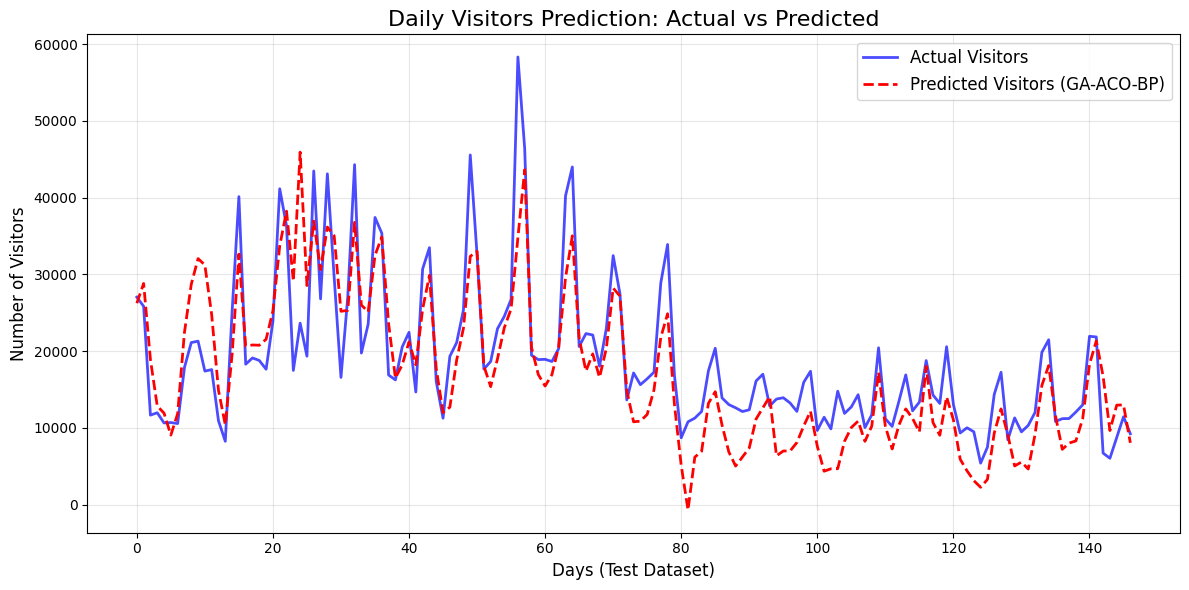

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

# --- 1. 최종 학습(Train) 환경 설정 ---
# 논문의 우수성을 증명하기 위해 반복 횟수(Epoch)를 200번으로 아주 짧게 줍니다.
epochs = 200
# AI가 학습할 때 발걸음 보폭(Learning Rate)을 설정합니다.
optimizer = optim.Adam(bp_model.parameters(), lr=0.01)
# 오차 측정 방식 (평균 제곱 오차)
loss_fn = nn.MSELoss()

print("🏃‍♂️ BP 신경망 최종 학습을 시작합니다...\n")

# --- 2. 모델 학습 (Train Loop) ---
bp_model.train() # 모델을 학습 모드로 전환
for epoch in range(epochs):
    optimizer.zero_grad()                 # 이전 계산의 찌꺼기(기울기) 초기화
    pred = bp_model(X_train_tensor)       # 예측
    loss = loss_fn(pred, y_train_tensor)  # 정답과 비교하여 오차 계산
    loss.backward()                       # 오차를 줄이는 방향 계산 (역전파)
    optimizer.step()                      # 가중치 업데이트

    if (epoch+1) % 20 == 0:
        print(f"▶ Epoch {epoch+1:3d}/{epochs} | 현재 학습 오차(MSE): {loss.item():.4f}")

# --- 3. 실전 테스트 (Test) ---
print("\n🎯 학습되지 않은 새로운 데이터(Test)로 예측 능력을 평가합니다.")
bp_model.eval() # 모델을 평가 모드로 전환 (가중치 고정)
with torch.no_grad():
    test_pred = bp_model(X_test_tensor)
    test_loss = loss_fn(test_pred, y_test_tensor).item()
print(f"최종 실전 평가 오차(Test MSE): {test_loss:.4f}")

# --- 4. 데이터 원래 단위(명)로 복구 ---
# 0~1 사이로 압축했던 데이터를 실제 '방문객 수(명)'로 되돌립니다.
actual_visitors = scaler_y.inverse_transform(y_test_tensor.numpy())
predicted_visitors = scaler_y.inverse_transform(test_pred.numpy())

# --- 5. 결과 시각화 (Graph) ---
# 코랩 한글 깨짐 방지를 위해 그래프 레이블은 영문으로 작성했습니다.
plt.figure(figsize=(12, 6))
plt.plot(actual_visitors, label='Actual Visitors', color='blue', alpha=0.7, linewidth=2)
plt.plot(predicted_visitors, label='Predicted Visitors (GA-ACO-BP)', color='red', linestyle='--', linewidth=2)
plt.title('Daily Visitors Prediction: Actual vs Predicted', fontsize=16)
plt.xlabel('Days (Test Dataset)', fontsize=12)
plt.ylabel('Number of Visitors', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# 1. 4대 평가 지표 계산
# RMSE (Root Mean Squared Error): 오차의 제곱 평균에 루트를 씌운 값 (이상치에 민감, 작을수록 좋음)
rmse = np.sqrt(mean_squared_error(actual_visitors, predicted_visitors))

# MAE (Mean Absolute Error): 실제값과 예측값 차이의 절댓값 평균 (작을수록 좋음)
mae = mean_absolute_error(actual_visitors, predicted_visitors)

# R² (R-Squared, 결정계수): 모델이 실제 데이터의 분산을 얼마나 잘 설명하는가 (1에 가까울수록 완벽함)
r2 = r2_score(actual_visitors, predicted_visitors)

# MAPE (Mean Absolute Percentage Error): 실제값 대비 오차의 비율 (%) (작을수록 좋음)
mape = mean_absolute_percentage_error(actual_visitors, predicted_visitors) * 100

# 2. 결과 출력
print("📊 GA-ACO-BP 모델 최종 평가 지표 📊")
print("-" * 40)
print(f"🔹 RMSE (평균 제곱근 오차)   : {rmse:8.2f} 명")
print(f"🔹 MAE  (평균 절대 오차)     : {mae:8.2f} 명")
print(f"🔹 MAPE (평균 오차율)        : {mape:8.2f} %")
print(f"🔹 R²   (결정계수/설명력)    : {r2:8.4f}")
print("-" * 40)

📊 GA-ACO-BP 모델 최종 평가 지표 📊
----------------------------------------
🔹 RMSE (평균 제곱근 오차)   :  5662.68 명
🔹 MAE  (평균 절대 오차)     :  4418.46 명
🔹 MAPE (평균 오차율)        :    26.99 %
🔹 R²   (결정계수/설명력)    :   0.6526
----------------------------------------


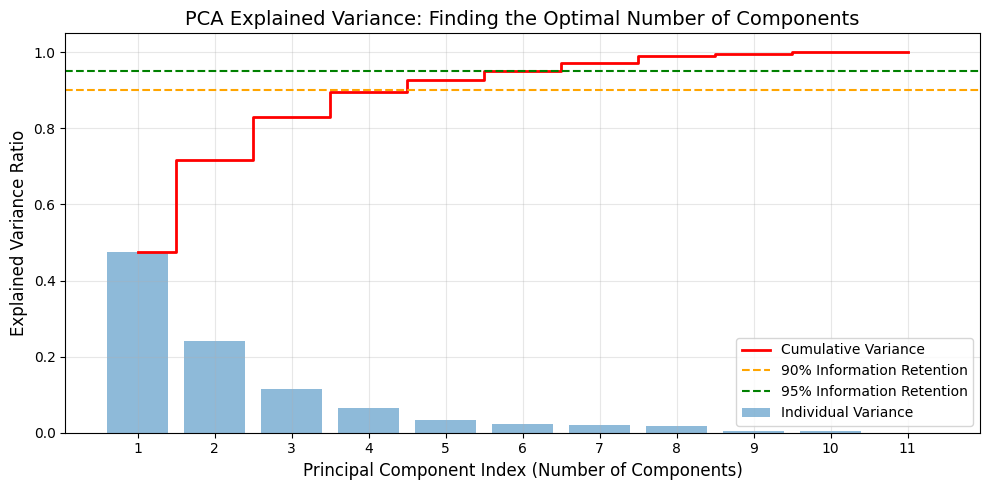

🔍 주성분 개수에 따른 데이터 정보 보존율 🔍
---------------------------------------------
주성분  1개 사용 시: 원본 데이터의  47.41% 설명 가능
주성분  2개 사용 시: 원본 데이터의  71.64% 설명 가능
주성분  3개 사용 시: 원본 데이터의  83.08% 설명 가능
주성분  4개 사용 시: 원본 데이터의  89.59% 설명 가능
주성분  5개 사용 시: 원본 데이터의  92.86% 설명 가능
주성분  6개 사용 시: 원본 데이터의  95.20% 설명 가능
주성분  7개 사용 시: 원본 데이터의  97.29% 설명 가능
주성분  8개 사용 시: 원본 데이터의  99.11% 설명 가능
주성분  9개 사용 시: 원본 데이터의  99.59% 설명 가능
주성분 10개 사용 시: 원본 데이터의  99.98% 설명 가능
주성분 11개 사용 시: 원본 데이터의 100.00% 설명 가능
---------------------------------------------


In [ ]:
## 주성분분석
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# 1. PCA 모델 생성 및 학습 (이미 0~1로 스케일링된 X_train 데이터 사용)
# 일단 11개 차원 전체를 기준으로 PCA를 피팅해 봅니다.
pca_explorer = PCA()
pca_explorer.fit(X_train)

# 2. 각 주성분이 설명하는 데이터의 분산(정보량) 비율 계산
variance_ratio = pca_explorer.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

# 3. 최적의 주성분 개수를 찾기 위한 시각화
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(variance_ratio) + 1), variance_ratio, alpha=0.5, align='center', label='Individual Variance')
plt.step(range(1, len(variance_ratio) + 1), cumulative_variance, where='mid', label='Cumulative Variance', color='red', linewidth=2)

# 데이터의 90%와 95% 정보를 보존하는 기준선(Threshold) 긋기
plt.axhline(y=0.90, color='orange', linestyle='--', label='90% Information Retention')
plt.axhline(y=0.95, color='green', linestyle='--', label='95% Information Retention')

plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.xlabel('Principal Component Index (Number of Components)', fontsize=12)
plt.title('PCA Explained Variance: Finding the Optimal Number of Components', fontsize=14)
plt.xticks(range(1, len(variance_ratio) + 1))
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. 누적 분산량 텍스트로 확인
print("🔍 주성분 개수에 따른 데이터 정보 보존율 🔍")
print("-" * 45)
for i, cum_var in enumerate(cumulative_variance):
    print(f"주성분 {i+1:2d}개 사용 시: 원본 데이터의 {cum_var*100:6.2f}% 설명 가능")
print("-" * 45)

🔄 1. 데이터 전처리 시작
🧠 2. 튜닝된 BP 신경망 구축
🧬 3. GA 전역 탐색 시작 (엘리트 보존 법칙 적용)...
🐜 4. ACO 국소 탐색 시작...
🏃‍♂️ 5. Adam 옵티마이저 미세 조정 (L2 정규화 적용)...

📊 [안정화된 GA-ACO-BP 모델] 최종 평가 지표 📊
----------------------------------------
🔹 RMSE :  5816.71 명
🔹 MAE  :  3264.91 명
🔹 MAPE :    16.91 %
🔹 R²   :   0.6335
----------------------------------------


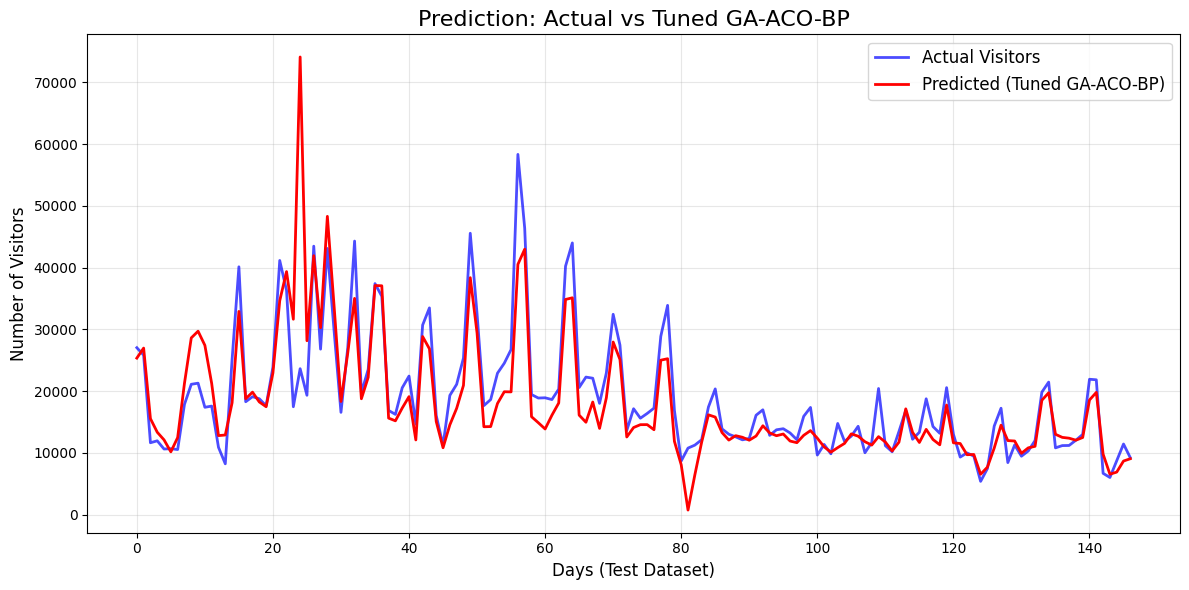


🕵️‍♂️ [예측 오차 상위 5일 데이터 분석]

❌ Test Dataset 24일 차 (오차: 50464명 차이)
   ▶ 실제 방문객: 23637명 / 모델 예측: 74101명
   ▶ 당일 데이터 원본 특성:
{'입장일': '2024-10-01', '총입장객수': 23637, '휴일유형': 2, '전날_방문객': 17477.0, '전전날_방문객': 36325.0, '작년동기_방문객': 41766.0, '평균기온(°C)': 18.3, '최저기온(°C)': 13.3, '최고기온(°C)': 21.7, '일강수량(mm)': 2.5, '평균 풍속(m/s)': 2.5, '일 최심신적설(cm)': 0.0, '검색량': 4.61512051684126}

❌ Test Dataset 56일 차 (오차: 17801명 차이)
   ▶ 실제 방문객: 58331명 / 모델 예측: 40530명
   ▶ 당일 데이터 원본 특성:
{'입장일': '2024-11-02', '총입장객수': 58331, '휴일유형': 1, '전날_방문객': 26740.0, '전전날_방문객': 24524.0, '작년동기_방문객': 16620.0, '평균기온(°C)': 18.1, '최저기온(°C)': 13.0, '최고기온(°C)': 25.1, '일강수량(mm)': 0.0, '평균 풍속(m/s)': 1.9, '일 최심신적설(cm)': 0.0, '검색량': 2.72581807996256}

❌ Test Dataset 23일 차 (오차: 14169명 차이)
   ▶ 실제 방문객: 17477명 / 모델 예측: 31646명
   ▶ 당일 데이터 원본 특성:
{'입장일': '2024-09-30', '총입장객수': 17477, '휴일유형': 0, '전날_방문객': 36325.0, '전전날_방문객': 41158.0, '작년동기_방문객': 45302.0, '평균기온(°C)': 23.0, '최저기온(°C)': 18.3, '최고기온(°C)': 28.5, '일강수량(mm)': 0.0, '평균 풍속(m/s)': 2.1, '일 최심신

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# --- 0. 난수 시드 고정 (완벽한 재현성을 원할 경우 주석 해제) ---
# seed = 42
# np.random.seed(seed)
# torch.manual_seed(seed)
# random.seed(seed)

print("🔄 1. 데이터 전처리 시작")
file_path = "data/어린이대공원_GA_ACO_BP_마스터데이터.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")
df = df.ffill().bfill()
df['검색량'] = np.log1p(df['검색량'])

X_data = df.drop(columns=['입장일', '총입장객수']).values
y_data = df['총입장객수'].values.reshape(-1, 1)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

train_size = int(len(X_scaled) * 0.8)
X_train_tensor = torch.FloatTensor(X_scaled[:train_size])
y_train_tensor = torch.FloatTensor(y_scaled[:train_size])
X_test_tensor = torch.FloatTensor(X_scaled[train_size:])
y_test_tensor = torch.FloatTensor(y_scaled[train_size:])

print("🧠 2. 튜닝된 BP 신경망 구축")
class Tuned_BP_Network(nn.Module):
    def __init__(self, input_size=11, hidden1=32, hidden2=16, output_size=1):
        super(Tuned_BP_Network, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, output_size)
        )
    def forward(self, x):
        return self.net(x)

bp_model = Tuned_BP_Network()
loss_fn = nn.MSELoss()

def get_params(model):
    return np.concatenate([p.data.cpu().numpy().flatten() for p in model.parameters()])
def set_params(model, chromosome):
    idx = 0
    for p in model.parameters():
        size = p.numel()
        p.data = torch.tensor(chromosome[idx:idx+size].reshape(p.shape)).float()
        idx += size

def evaluate_bp(chromosome):
    set_params(bp_model, chromosome)
    bp_model.eval()
    with torch.no_grad():
        pred = bp_model(X_train_tensor)
        return loss_fn(pred, y_train_tensor).item()

num_params = len(get_params(bp_model))

print("🧬 3. GA 전역 탐색 시작 (엘리트 보존 법칙 적용)...")
POP_SIZE = 50
GENERATIONS = 50

# 스마트 초기화: 개체군 생성 시 1번 유전자는 PyTorch 기본 가중치를 그대로 사용
population = np.random.uniform(-1.0, 1.0, (POP_SIZE, num_params))
population[0] = get_params(Tuned_BP_Network()) # 강력한 베이스라인 주입

best_fitness = float('inf')
best_ga_chromosome = None

for gen in range(GENERATIONS):
    fitness_scores = np.array([evaluate_bp(ind) for ind in population])

    # 순위 매기기
    sorted_indices = np.argsort(fitness_scores)

    if fitness_scores[sorted_indices[0]] < best_fitness:
        best_fitness = fitness_scores[sorted_indices[0]]
        best_ga_chromosome = population[sorted_indices[0]].copy()

    # ★ 안정성 핵심: 상위 20% 엘리트는 변형 없이 그대로 다음 세대로 복사 ★
    elite_count = int(POP_SIZE * 0.2)
    new_population = [population[i].copy() for i in sorted_indices[:elite_count]]

    # 하위 80%는 토너먼트로 채우기
    for _ in range(POP_SIZE - elite_count):
        candidates = np.random.choice(POP_SIZE, 3, replace=False)
        winner = candidates[np.argmin(fitness_scores[candidates])]
        new_population.append(population[winner])
    new_population = np.array(new_population)

    # 교차 (엘리트는 제외하고 적용)
    for i in range(elite_count, POP_SIZE, 2):
        if i+1 < POP_SIZE and np.random.rand() < 0.8:
            crossover_point = np.random.randint(1, num_params)
            p1, p2 = new_population[i].copy(), new_population[i+1].copy()
            new_population[i, crossover_point:] = p2[crossover_point:]
            new_population[i+1, crossover_point:] = p1[crossover_point:]

    # 돌연변이 (엘리트는 제외하고 적용)
    for i in range(elite_count, POP_SIZE):
        if np.random.rand() < 0.15:
            mutation_indices = np.random.choice(num_params, size=int(num_params * 0.1), replace=False)
            new_population[i, mutation_indices] += np.random.uniform(-0.5, 0.5, size=len(mutation_indices))

    population = new_population

print("🐜 4. ACO 국소 탐색 시작...")
pheromone_center = best_ga_chromosome.copy()
search_radius = 0.2
best_aco_fitness = best_fitness
best_aco_chromosome = pheromone_center.copy()

for iteration in range(30):
    ants = np.array([pheromone_center + np.random.normal(0, search_radius, num_params) for _ in range(30)])
    # ACO에도 스마트 초기화: 개미 중 1마리는 이전 탐색 중심을 그대로 유지 (퇴보 방지)
    ants[0] = pheromone_center.copy()

    ant_fitness = np.array([evaluate_bp(ant) for ant in ants])
    current_best_idx = np.argmin(ant_fitness)

    if ant_fitness[current_best_idx] < best_aco_fitness:
        best_aco_fitness = ant_fitness[current_best_idx]
        best_aco_chromosome = ants[current_best_idx].copy()

    pheromone_center = 0.8 * pheromone_center + 0.2 * ants[current_best_idx]
    search_radius *= 0.95

set_params(bp_model, best_aco_chromosome)

print("🏃‍♂️ 5. Adam 옵티마이저 미세 조정 (L2 정규화 적용)...")
# ★ weight_decay(L2 정규화) 추가로 오버피팅을 억제하여 평가 일관성 상승 ★
optimizer = optim.Adam(bp_model.parameters(), lr=0.005, weight_decay=1e-4)
bp_model.train()
for epoch in range(150):
    optimizer.zero_grad()
    pred = bp_model(X_train_tensor)
    loss = loss_fn(pred, y_train_tensor)
    loss.backward()
    optimizer.step()

# --- 6. 실전 테스트 및 지표 평가 ---
bp_model.eval()
with torch.no_grad():
    test_pred_bp = bp_model(X_test_tensor)

actual_visitors = scaler_y.inverse_transform(y_test_tensor.numpy())
predicted_visitors_bp = scaler_y.inverse_transform(test_pred_bp.numpy())

rmse = np.sqrt(mean_squared_error(actual_visitors, predicted_visitors_bp))
mae = mean_absolute_error(actual_visitors, predicted_visitors_bp)
r2 = r2_score(actual_visitors, predicted_visitors_bp)
mape = mean_absolute_percentage_error(actual_visitors, predicted_visitors_bp) * 100

print("\n📊 [안정화된 GA-ACO-BP 모델] 최종 평가 지표 📊")
print("-" * 40)
print(f"🔹 RMSE : {rmse:8.2f} 명")
print(f"🔹 MAE  : {mae:8.2f} 명")
print(f"🔹 MAPE : {mape:8.2f} %")
print(f"🔹 R²   : {r2:8.4f}")
print("-" * 40)

# --- 7. 결과 시각화 ---
plt.figure(figsize=(12, 6))
plt.plot(actual_visitors, label='Actual Visitors', color='blue', alpha=0.7, linewidth=2)
plt.plot(predicted_visitors_bp, label='Predicted (Tuned GA-ACO-BP)', color='red', linestyle='-', linewidth=2)
plt.title('Prediction: Actual vs Tuned GA-ACO-BP', fontsize=16)
plt.xlabel('Days (Test Dataset)', fontsize=12)
plt.ylabel('Number of Visitors', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8. 오차가 가장 큰 '오답 노트' 추출 ---
print("\n🕵️‍♂️ [예측 오차 상위 5일 데이터 분석]")
# 절대 오차 계산
errors = np.abs(actual_visitors.flatten() - predicted_visitors_bp.flatten())

# 결과를 보기 쉽게 데이터프레임으로 묶기
error_df = pd.DataFrame({
    'Test_Day_Index': np.arange(len(actual_visitors)),
    'Actual_Visitors': actual_visitors.flatten(),
    'Predicted_Visitors': predicted_visitors_bp.flatten(),
    'Error': errors
})

# 오차가 가장 큰 순서대로 5개 추출
top_errors = error_df.sort_values(by='Error', ascending=False).head(5)

# 전체 마스터 데이터 중 Test 구간의 실제 데이터 원본 가져오기 (스케일링 전 원본)
# (Train 80%, Test 20% 분할이므로, 하위 20% 인덱스 추출)
test_start_idx = len(df) - len(actual_visitors)
original_test_df = df.iloc[test_start_idx:].reset_index(drop=True)

for i, row in top_errors.iterrows():
    idx = int(row['Test_Day_Index'])
    print(f"\n❌ Test Dataset {idx}일 차 (오차: {row['Error']:.0f}명 차이)")
    print(f"   ▶ 실제 방문객: {row['Actual_Visitors']:.0f}명 / 모델 예측: {row['Predicted_Visitors']:.0f}명")
    print(f"   ▶ 당일 데이터 원본 특성:")
    # 해당 날짜의 주요 특성 11개 출력 (입력하신 마스터 데이터의 컬럼들이 출력됩니다)
    print(original_test_df.iloc[idx].to_dict())

🔄 1. 업그레이드 데이터 전처리 시작
🧠 2. 튜닝된 BP 신경망 구축 (입력 변수 15개로 확장)
🧬 3. GA 전역 탐색 시작 (엘리트 보존 법칙 적용)...
🐜 4. ACO 국소 탐색 시작...
🏃‍♂️ 5. Adam 옵티마이저 미세 조정 (L2 정규화 적용)...

📊 [업그레이드된 데이터 적용 GA-ACO-BP 모델] 최종 평가 지표 📊
----------------------------------------
🔹 RMSE :  5618.01 명
🔹 MAE  :  3075.99 명
🔹 MAPE :    15.57 %
🔹 R²   :   0.6581
----------------------------------------


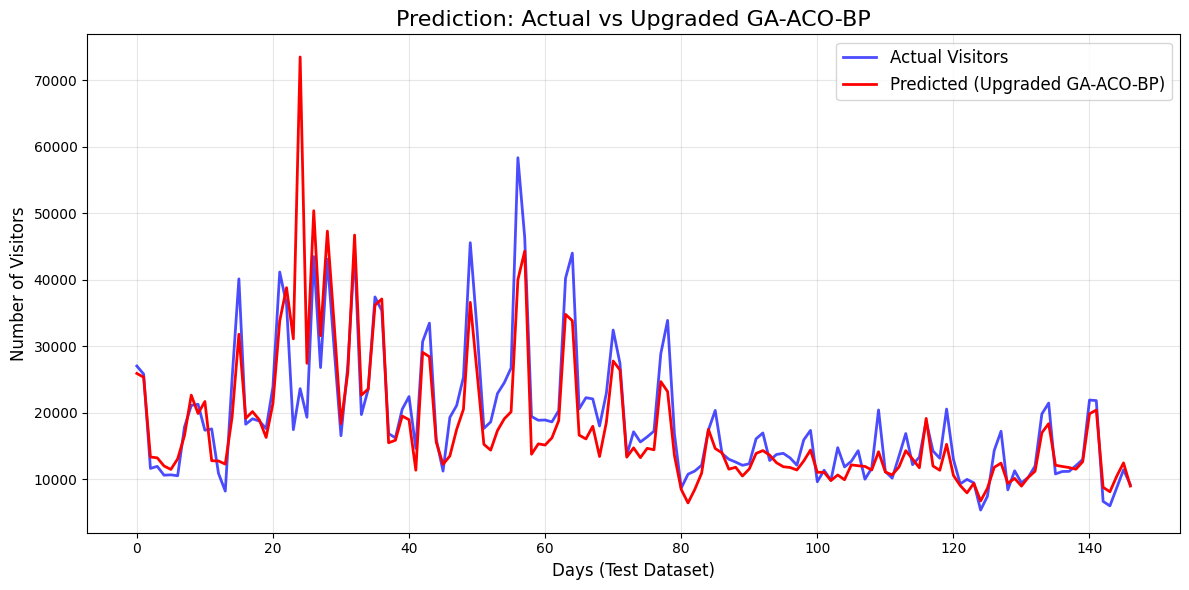


🕵️‍♂️ [예측 오차 상위 5일 데이터 분석]

❌ Test Dataset 24일 차 (오차: 49829명 차이)
   ▶ 실제 방문객: 23637명 / 모델 예측: 73466명
   ▶ 당일 데이터 원본 특성 (일부 핵심 변수 확인):
{'입장일': '2024-10-01', '총입장객수': np.int64(23637), '휴일유형': np.int64(2), '전주_동요일_방문객': np.float64(19105.0), '명절인가': np.int64(0), '비가왔는가': np.int64(1), '폭염인가': np.int64(0), '일강수량(mm)': np.float64(2.5), '최고기온(°C)': np.float64(21.7)}

❌ Test Dataset 56일 차 (오차: 18325명 차이)
   ▶ 실제 방문객: 58331명 / 모델 예측: 40006명
   ▶ 당일 데이터 원본 특성 (일부 핵심 변수 확인):
{'입장일': '2024-11-02', '총입장객수': np.int64(58331), '휴일유형': np.int64(1), '전주_동요일_방문객': np.float64(45563.0), '명절인가': np.int64(0), '비가왔는가': np.int64(0), '폭염인가': np.int64(0), '일강수량(mm)': np.float64(0.0), '최고기온(°C)': np.float64(25.1)}

❌ Test Dataset 23일 차 (오차: 13645명 차이)
   ▶ 실제 방문객: 17477명 / 모델 예측: 31122명
   ▶ 당일 데이터 원본 특성 (일부 핵심 변수 확인):
{'입장일': '2024-09-30', '총입장객수': np.int64(17477), '휴일유형': np.int64(0), '전주_동요일_방문객': np.float64(18289.0), '명절인가': np.int64(0), '비가왔는가': np.int64(0), '폭염인가': np.int64(0), '일강수량(mm)': np.float64(0.0), 

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

print("🔄 1. 업그레이드 데이터 전처리 시작")
# 새로 저장하신 파일 경로로 수정되었습니다.
file_path = "data/어린이대공원_업그레이드_마스터데이터.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")
df = df.ffill().bfill()

# 검색량 로그 변환 유지 (검색량 컬럼이 있을 경우)
if '검색량' in df.columns:
    df['검색량'] = np.log1p(df['검색량'])

# X_data와 y_data 분리
X_data = df.drop(columns=['입장일', '총입장객수']).values
y_data = df['총입장객수'].values.reshape(-1, 1)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

train_size = int(len(X_scaled) * 0.8)
X_train_tensor = torch.FloatTensor(X_scaled[:train_size])
y_train_tensor = torch.FloatTensor(y_scaled[:train_size])
X_test_tensor = torch.FloatTensor(X_scaled[train_size:])
y_test_tensor = torch.FloatTensor(y_scaled[train_size:])

print("🧠 2. 튜닝된 BP 신경망 구축 (입력 변수 15개로 확장)")
class Tuned_BP_Network(nn.Module):
    # ★ 핵심 수정: 추가된 피처 4개를 반영하여 input_size를 15로 변경 ★
    def __init__(self, input_size=15, hidden1=32, hidden2=16, output_size=1):
        super(Tuned_BP_Network, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, output_size)
        )
    def forward(self, x):
        return self.net(x)

bp_model = Tuned_BP_Network()
loss_fn = nn.MSELoss()

def get_params(model):
    return np.concatenate([p.data.cpu().numpy().flatten() for p in model.parameters()])
def set_params(model, chromosome):
    idx = 0
    for p in model.parameters():
        size = p.numel()
        p.data = torch.tensor(chromosome[idx:idx+size].reshape(p.shape)).float()
        idx += size

def evaluate_bp(chromosome):
    set_params(bp_model, chromosome)
    bp_model.eval()
    with torch.no_grad():
        pred = bp_model(X_train_tensor)
        return loss_fn(pred, y_train_tensor).item()

num_params = len(get_params(bp_model))

print("🧬 3. GA 전역 탐색 시작 (엘리트 보존 법칙 적용)...")
POP_SIZE = 50
GENERATIONS = 50

# 스마트 초기화: 1번 유전자는 파이토치 기본 가중치 주입
population = np.random.uniform(-1.0, 1.0, (POP_SIZE, num_params))
population[0] = get_params(Tuned_BP_Network(input_size=15))

best_fitness = float('inf')
best_ga_chromosome = None

for gen in range(GENERATIONS):
    fitness_scores = np.array([evaluate_bp(ind) for ind in population])
    sorted_indices = np.argsort(fitness_scores)

    if fitness_scores[sorted_indices[0]] < best_fitness:
        best_fitness = fitness_scores[sorted_indices[0]]
        best_ga_chromosome = population[sorted_indices[0]].copy()

    # 상위 20% 엘리트 보존
    elite_count = int(POP_SIZE * 0.2)
    new_population = [population[i].copy() for i in sorted_indices[:elite_count]]

    # 하위 80% 토너먼트 선택
    for _ in range(POP_SIZE - elite_count):
        candidates = np.random.choice(POP_SIZE, 3, replace=False)
        winner = candidates[np.argmin(fitness_scores[candidates])]
        new_population.append(population[winner])
    new_population = np.array(new_population)

    # 교차 및 돌연변이 (엘리트 제외)
    for i in range(elite_count, POP_SIZE, 2):
        if i+1 < POP_SIZE and np.random.rand() < 0.8:
            crossover_point = np.random.randint(1, num_params)
            p1, p2 = new_population[i].copy(), new_population[i+1].copy()
            new_population[i, crossover_point:] = p2[crossover_point:]
            new_population[i+1, crossover_point:] = p1[crossover_point:]

    for i in range(elite_count, POP_SIZE):
        if np.random.rand() < 0.15:
            mutation_indices = np.random.choice(num_params, size=int(num_params * 0.1), replace=False)
            new_population[i, mutation_indices] += np.random.uniform(-0.5, 0.5, size=len(mutation_indices))

    population = new_population

print("🐜 4. ACO 국소 탐색 시작...")
pheromone_center = best_ga_chromosome.copy()
search_radius = 0.2
best_aco_fitness = best_fitness
best_aco_chromosome = pheromone_center.copy()

for iteration in range(30):
    ants = np.array([pheromone_center + np.random.normal(0, search_radius, num_params) for _ in range(30)])
    ants[0] = pheromone_center.copy() # 퇴보 방지

    ant_fitness = np.array([evaluate_bp(ant) for ant in ants])
    current_best_idx = np.argmin(ant_fitness)

    if ant_fitness[current_best_idx] < best_aco_fitness:
        best_aco_fitness = ant_fitness[current_best_idx]
        best_aco_chromosome = ants[current_best_idx].copy()

    pheromone_center = 0.8 * pheromone_center + 0.2 * ants[current_best_idx]
    search_radius *= 0.95

set_params(bp_model, best_aco_chromosome)

print("🏃‍♂️ 5. Adam 옵티마이저 미세 조정 (L2 정규화 적용)...")
optimizer = optim.Adam(bp_model.parameters(), lr=0.005, weight_decay=1e-4)
bp_model.train()
for epoch in range(150):
    optimizer.zero_grad()
    pred = bp_model(X_train_tensor)
    loss = loss_fn(pred, y_train_tensor)
    loss.backward()
    optimizer.step()

# --- 6. 실전 테스트 및 지표 평가 ---
bp_model.eval()
with torch.no_grad():
    test_pred_bp = bp_model(X_test_tensor)

actual_visitors = scaler_y.inverse_transform(y_test_tensor.numpy())
predicted_visitors_bp = scaler_y.inverse_transform(test_pred_bp.numpy())

rmse = np.sqrt(mean_squared_error(actual_visitors, predicted_visitors_bp))
mae = mean_absolute_error(actual_visitors, predicted_visitors_bp)
r2 = r2_score(actual_visitors, predicted_visitors_bp)
mape = mean_absolute_percentage_error(actual_visitors, predicted_visitors_bp) * 100

print("\n📊 [업그레이드된 데이터 적용 GA-ACO-BP 모델] 최종 평가 지표 📊")
print("-" * 40)
print(f"🔹 RMSE : {rmse:8.2f} 명")
print(f"🔹 MAE  : {mae:8.2f} 명")
print(f"🔹 MAPE : {mape:8.2f} %")
print(f"🔹 R²   : {r2:8.4f}")
print("-" * 40)

# --- 7. 결과 시각화 ---
plt.figure(figsize=(12, 6))
plt.plot(actual_visitors, label='Actual Visitors', color='blue', alpha=0.7, linewidth=2)
plt.plot(predicted_visitors_bp, label='Predicted (Upgraded GA-ACO-BP)', color='red', linestyle='-', linewidth=2)
plt.title('Prediction: Actual vs Upgraded GA-ACO-BP', fontsize=16)
plt.xlabel('Days (Test Dataset)', fontsize=12)
plt.ylabel('Number of Visitors', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8. 오차 분석 (새 피처들이 얼마나 활약했는지 확인) ---
print("\n🕵️‍♂️ [예측 오차 상위 5일 데이터 분석]")
errors = np.abs(actual_visitors.flatten() - predicted_visitors_bp.flatten())

error_df = pd.DataFrame({
    'Test_Day_Index': np.arange(len(actual_visitors)),
    'Actual_Visitors': actual_visitors.flatten(),
    'Predicted_Visitors': predicted_visitors_bp.flatten(),
    'Error': errors
})

top_errors = error_df.sort_values(by='Error', ascending=False).head(5)
test_start_idx = len(df) - len(actual_visitors)
original_test_df = df.iloc[test_start_idx:].reset_index(drop=True)

for i, row in top_errors.iterrows():
    idx = int(row['Test_Day_Index'])
    print(f"\n❌ Test Dataset {idx}일 차 (오차: {row['Error']:.0f}명 차이)")
    print(f"   ▶ 실제 방문객: {row['Actual_Visitors']:.0f}명 / 모델 예측: {row['Predicted_Visitors']:.0f}명")
    print(f"   ▶ 당일 데이터 원본 특성 (일부 핵심 변수 확인):")
    # 주요 피처들만 뽑아서 출력하여 보기 쉽게 구성
    important_cols = ['입장일', '총입장객수', '휴일유형', '전주_동요일_방문객', '명절인가', '비가왔는가', '폭염인가', '일강수량(mm)', '최고기온(°C)']
    display_data = {col: original_test_df.iloc[idx].get(col, "N/A") for col in important_cols}
    print(display_data)

🔄 1. 최종 데이터셋 전처리 시작
🧠 2. 최종 BP 신경망 구축 (★입력 변수 18개로 확장★)
🧬 3. GA 전역 탐색 시작 (50세대, 엘리트 보존)...
🐜 4. ACO 국소 탐색 시작 (30회)...
🏃‍♂️ 5. Adam 옵티마이저 미세 조정 (L2 정규화 적용, Epoch 150)...

📊 [최종 데이터 적용 GA-ACO-BP 모델] 최종 평가 지표 📊
----------------------------------------
🔹 RMSE :  4076.31 명
🔹 MAE  :  3109.26 명
🔹 MAPE :    16.88 %
🔹 R²   :   0.8200
----------------------------------------


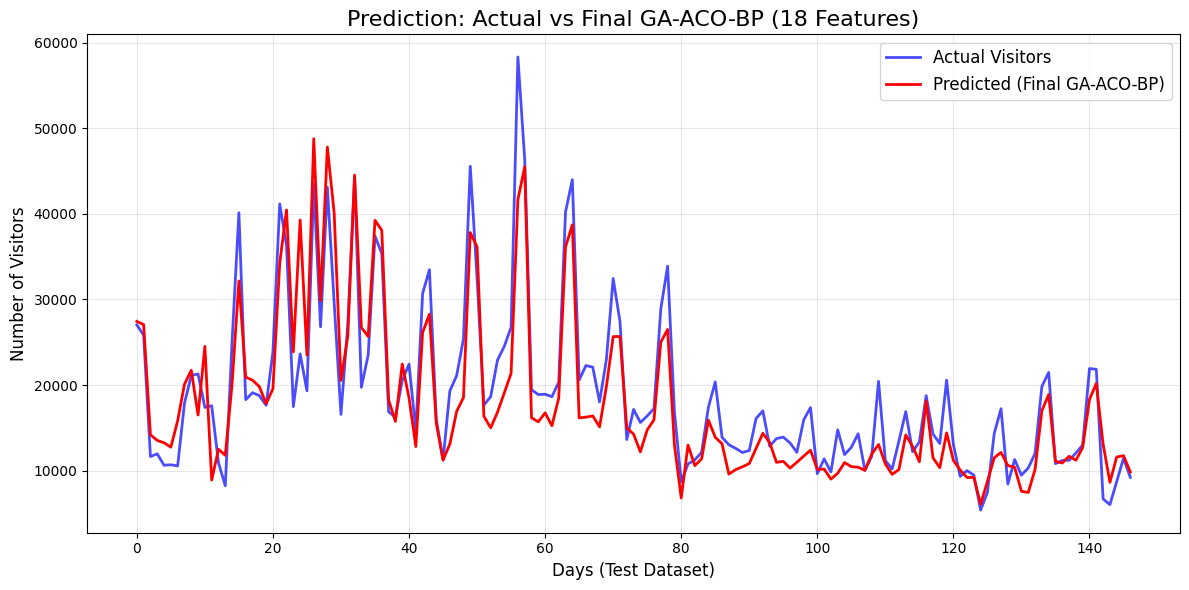


🕵️‍♂️ [예측 오차 상위 5일 데이터 분석]

❌ Test Dataset 56일 차 (오차: 16663명 차이)
   ▶ 실제 방문객: 58331명 / 모델 예측: 41668명
   ▶ 당일 데이터 주요 특성 (새 피처들 집중 확인):
{'입장일': '2024-11-02', '총입장객수': np.int64(58331), '휴일유형': np.int64(1), '비가왔는가': np.int64(0), '휴일_우천_페널티': np.int64(0), '임시공휴일_여부': np.int64(0), '징검다리_휴일_여부': np.int64(0), '명절인가': np.int64(0), '폭염인가': np.int64(0), '전주_동요일_방문객': np.float64(45563.0)}

❌ Test Dataset 24일 차 (오차: 15649명 차이)
   ▶ 실제 방문객: 23637명 / 모델 예측: 39286명
   ▶ 당일 데이터 주요 특성 (새 피처들 집중 확인):
{'입장일': '2024-10-01', '총입장객수': np.int64(23637), '휴일유형': np.int64(2), '비가왔는가': np.int64(1), '휴일_우천_페널티': np.int64(2), '임시공휴일_여부': np.int64(1), '징검다리_휴일_여부': np.int64(0), '명절인가': np.int64(0), '폭염인가': np.int64(0), '전주_동요일_방문객': np.float64(19105.0)}

❌ Test Dataset 29일 차 (오차: 10485명 차이)
   ▶ 실제 방문객: 29632명 / 모델 예측: 40117명
   ▶ 당일 데이터 주요 특성 (새 피처들 집중 확인):
{'입장일': '2024-10-06', '총입장객수': np.int64(29632), '휴일유형': np.int64(1), '비가왔는가': np.int64(0), '휴일_우천_페널티': np.int64(0), '임시공휴일_여부': np.int64(0), '징검다리_휴일_여부': np.

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

print("🔄 1. 최종 데이터셋 전처리 시작")
# 저장하신 '최종' 데이터셋 경로로 불러옵니다.
file_path = "data/어린이대공원_최종_마스터데이터.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")
df = df.ffill().bfill()

# 검색량 스파이크 방지용 로그 변환
if '검색량' in df.columns:
    df['검색량'] = np.log1p(df['검색량'])

# 독립변수(X)와 종속변수(y) 분리
X_data = df.drop(columns=['입장일', '총입장객수']).values
y_data = df['총입장객수'].values.reshape(-1, 1)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

train_size = int(len(X_scaled) * 0.8)
X_train_tensor = torch.FloatTensor(X_scaled[:train_size])
y_train_tensor = torch.FloatTensor(y_scaled[:train_size])
X_test_tensor = torch.FloatTensor(X_scaled[train_size:])
y_test_tensor = torch.FloatTensor(y_scaled[train_size:])

print("🧠 2. 최종 BP 신경망 구축 (★입력 변수 18개로 확장★)")
class Final_BP_Network(nn.Module):
    # 추가된 7개의 파생 변수를 모두 수용하기 위해 input_size=18 로 설정
    def __init__(self, input_size=18, hidden1=32, hidden2=16, output_size=1):
        super(Final_BP_Network, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, output_size)
        )
    def forward(self, x):
        return self.net(x)

bp_model = Final_BP_Network()
loss_fn = nn.MSELoss()

def get_params(model):
    return np.concatenate([p.data.cpu().numpy().flatten() for p in model.parameters()])
def set_params(model, chromosome):
    idx = 0
    for p in model.parameters():
        size = p.numel()
        p.data = torch.tensor(chromosome[idx:idx+size].reshape(p.shape)).float()
        idx += size

def evaluate_bp(chromosome):
    set_params(bp_model, chromosome)
    bp_model.eval()
    with torch.no_grad():
        pred = bp_model(X_train_tensor)
        return loss_fn(pred, y_train_tensor).item()

num_params = len(get_params(bp_model))

print("🧬 3. GA 전역 탐색 시작 (50세대, 엘리트 보존)...")
POP_SIZE = 50
GENERATIONS = 50

# 스마트 초기화: 베이스라인 주입
population = np.random.uniform(-1.0, 1.0, (POP_SIZE, num_params))
population[0] = get_params(Final_BP_Network(input_size=18))

best_fitness = float('inf')
best_ga_chromosome = None

for gen in range(GENERATIONS):
    fitness_scores = np.array([evaluate_bp(ind) for ind in population])
    sorted_indices = np.argsort(fitness_scores)

    if fitness_scores[sorted_indices[0]] < best_fitness:
        best_fitness = fitness_scores[sorted_indices[0]]
        best_ga_chromosome = population[sorted_indices[0]].copy()

    elite_count = int(POP_SIZE * 0.2)
    new_population = [population[i].copy() for i in sorted_indices[:elite_count]]

    for _ in range(POP_SIZE - elite_count):
        candidates = np.random.choice(POP_SIZE, 3, replace=False)
        winner = candidates[np.argmin(fitness_scores[candidates])]
        new_population.append(population[winner])
    new_population = np.array(new_population)

    for i in range(elite_count, POP_SIZE, 2):
        if i+1 < POP_SIZE and np.random.rand() < 0.8:
            crossover_point = np.random.randint(1, num_params)
            p1, p2 = new_population[i].copy(), new_population[i+1].copy()
            new_population[i, crossover_point:] = p2[crossover_point:]
            new_population[i+1, crossover_point:] = p1[crossover_point:]

    for i in range(elite_count, POP_SIZE):
        if np.random.rand() < 0.15:
            mutation_indices = np.random.choice(num_params, size=int(num_params * 0.1), replace=False)
            new_population[i, mutation_indices] += np.random.uniform(-0.5, 0.5, size=len(mutation_indices))

    population = new_population

print("🐜 4. ACO 국소 탐색 시작 (30회)...")
pheromone_center = best_ga_chromosome.copy()
search_radius = 0.2
best_aco_fitness = best_fitness
best_aco_chromosome = pheromone_center.copy()

for iteration in range(30):
    ants = np.array([pheromone_center + np.random.normal(0, search_radius, num_params) for _ in range(30)])
    ants[0] = pheromone_center.copy()

    ant_fitness = np.array([evaluate_bp(ant) for ant in ants])
    current_best_idx = np.argmin(ant_fitness)

    if ant_fitness[current_best_idx] < best_aco_fitness:
        best_aco_fitness = ant_fitness[current_best_idx]
        best_aco_chromosome = ants[current_best_idx].copy()

    pheromone_center = 0.8 * pheromone_center + 0.2 * ants[current_best_idx]
    search_radius *= 0.95

set_params(bp_model, best_aco_chromosome)

print("🏃‍♂️ 5. Adam 옵티마이저 미세 조정 (L2 정규화 적용, Epoch 150)...")
optimizer = optim.Adam(bp_model.parameters(), lr=0.005, weight_decay=1e-4)
bp_model.train()
for epoch in range(150):
    optimizer.zero_grad()
    pred = bp_model(X_train_tensor)
    loss = loss_fn(pred, y_train_tensor)
    loss.backward()
    optimizer.step()

# --- 6. 실전 테스트 및 지표 평가 ---
bp_model.eval()
with torch.no_grad():
    test_pred_bp = bp_model(X_test_tensor)

actual_visitors = scaler_y.inverse_transform(y_test_tensor.numpy())
predicted_visitors_bp = scaler_y.inverse_transform(test_pred_bp.numpy())

rmse = np.sqrt(mean_squared_error(actual_visitors, predicted_visitors_bp))
mae = mean_absolute_error(actual_visitors, predicted_visitors_bp)
r2 = r2_score(actual_visitors, predicted_visitors_bp)
mape = mean_absolute_percentage_error(actual_visitors, predicted_visitors_bp) * 100

print("\n📊 [최종 데이터 적용 GA-ACO-BP 모델] 최종 평가 지표 📊")
print("-" * 40)
print(f"🔹 RMSE : {rmse:8.2f} 명")
print(f"🔹 MAE  : {mae:8.2f} 명")
print(f"🔹 MAPE : {mape:8.2f} %")
print(f"🔹 R²   : {r2:8.4f}")
print("-" * 40)

# --- 7. 결과 시각화 ---
plt.figure(figsize=(12, 6))
plt.plot(actual_visitors, label='Actual Visitors', color='blue', alpha=0.7, linewidth=2)
plt.plot(predicted_visitors_bp, label='Predicted (Final GA-ACO-BP)', color='red', linestyle='-', linewidth=2)
plt.title('Prediction: Actual vs Final GA-ACO-BP (18 Features)', fontsize=16)
plt.xlabel('Days (Test Dataset)', fontsize=12)
plt.ylabel('Number of Visitors', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8. 오차 분석 (최종 피처들의 영향력 확인) ---
print("\n🕵️‍♂️ [예측 오차 상위 5일 데이터 분석]")
errors = np.abs(actual_visitors.flatten() - predicted_visitors_bp.flatten())

error_df = pd.DataFrame({
    'Test_Day_Index': np.arange(len(actual_visitors)),
    'Actual_Visitors': actual_visitors.flatten(),
    'Predicted_Visitors': predicted_visitors_bp.flatten(),
    'Error': errors
})

top_errors = error_df.sort_values(by='Error', ascending=False).head(5)
test_start_idx = len(df) - len(actual_visitors)
original_test_df = df.iloc[test_start_idx:].reset_index(drop=True)

for i, row in top_errors.iterrows():
    idx = int(row['Test_Day_Index'])
    print(f"\n❌ Test Dataset {idx}일 차 (오차: {row['Error']:.0f}명 차이)")
    print(f"   ▶ 실제 방문객: {row['Actual_Visitors']:.0f}명 / 모델 예측: {row['Predicted_Visitors']:.0f}명")
    print(f"   ▶ 당일 데이터 주요 특성 (새 피처들 집중 확인):")

    # 새롭게 추가한 피처들이 잘 적용되어 판단을 내렸는지 확인하기 위한 컬럼 리스트
    important_cols = [
        '입장일', '총입장객수', '휴일유형', '비가왔는가',
        '휴일_우천_페널티', '임시공휴일_여부', '징검다리_휴일_여부',
        '명절인가', '폭염인가', '전주_동요일_방문객'
    ]
    display_data = {col: original_test_df.iloc[idx].get(col, "N/A") for col in important_cols}
    print(display_data)